# ASVspoof 2019: dataset study

Paper: [https://doi.org/10.1016/j.csl.2020.101114](https://doi.org/10.1016/j.csl.2020.101114) <br>
Download: [https://datashare.ed.ac.uk/handle/10283/3336](https://datashare.ed.ac.uk/handle/10283/3336)

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
from src.data_utils import ASVDataset
from IPython.display import Audio, display
from collections import Counter
import librosa
import matplotlib.pyplot as plt
from collections import Counter
import soundfile as sf
import numpy as np
import pandas as pd
import librosa

## Loading LA subset
For the purpose of this demo, we use raw audio without transformations or length alterations.

In [3]:
DATA_PATH = str(Path.cwd().parent / 'data' / 'ASVspoof2019_LA')
PROTOCOLS_PATH = str(Path.cwd().parent / 'data' / 'ASVspoof2019_LA' / 'ASVspoof2019_LA_cm_protocols')
CACHE_DIR = str(Path.cwd().parent / 'data_caches')

FEATURE_NAME = 'raw'

In [4]:
train_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH,transform=None, 
    is_train=True, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR
)

sysid_dict_inv {0: '-', 1: 'A01', 2: 'A02', 3: 'A03', 4: 'A04', 5: 'A05', 6: 'A06'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name train
protocols_fname train.trn
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_train/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_train_LA_raw.npy
Cache not found. Processing dataset...
Reading audio files...


Reading files:   0%|          | 0/25380 [00:00<?, ?file/s]

Saving cache to: /root/reproduction-salvi-et-al/data_caches/cache_train_LA_raw.npy
Cache saved successfully


In [5]:
dev_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH,transform=None, 
    is_train=False, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR
)

sysid_dict_inv {0: '-', 1: 'A01', 2: 'A02', 3: 'A03', 4: 'A04', 5: 'A05', 6: 'A06'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name dev
protocols_fname dev.trl
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_dev/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_raw.npy
Cache not found. Processing dataset...
Reading audio files...


Reading files:   0%|          | 0/24844 [00:00<?, ?file/s]

Saving cache to: /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_raw.npy
Cache saved successfully


In [6]:
eval_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH,transform=None, 
    is_eval=True, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR
)

sysid_dict_inv {0: '-', 1: 'A07', 2: 'A08', 3: 'A09', 4: 'A10', 5: 'A11', 6: 'A12', 7: 'A13', 8: 'A14', 9: 'A15', 10: 'A16', 11: 'A17', 12: 'A18', 13: 'A19'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name eval
protocols_fname eval.trl
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_eval/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_raw.npy
Cache not found. Processing dataset...
Reading audio files...


Reading files:   0%|          | 0/71237 [00:00<?, ?file/s]

Saving cache to: /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_raw.npy
Cache saved successfully


## Class distribution (bonafide vs spoof)

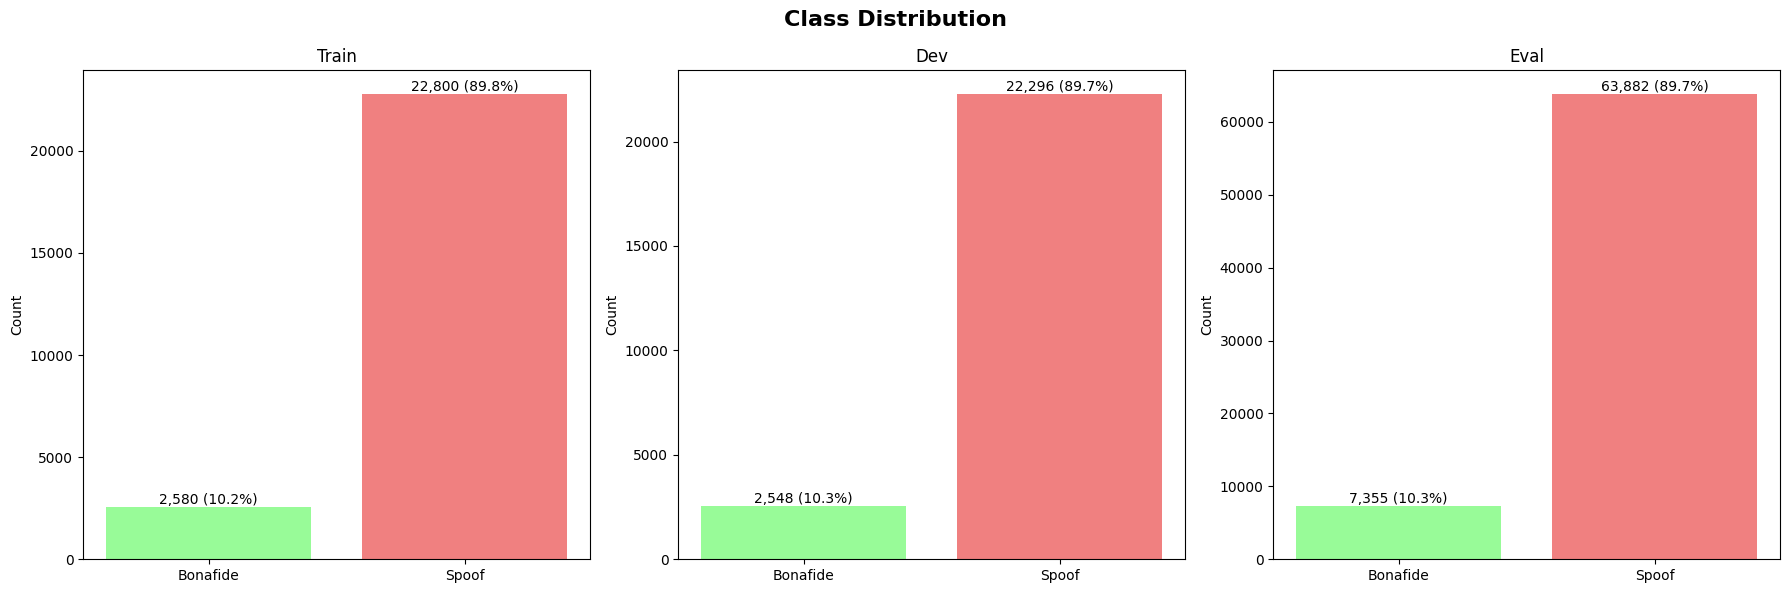

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, dataset in enumerate([train_data, dev_data, eval_data]):
    labels = list(map(int, dataset.data_y))
    bonafide = sum(labels)
    spoof = len(labels) - bonafide

    ax = axes[idx]
    ax.bar(['Bonafide', 'Spoof'], [bonafide, spoof], color=['palegreen', 'lightcoral'])
    ax.set_title(dataset.dset_name.capitalize())
    ax.set_ylabel('Count')
    
    for i, v in enumerate([bonafide, spoof]):
        ax.text(i, v, f'{v:,} ({v/len(labels)*100:.1f}%)', ha='center', va='bottom')

fig.suptitle('Class Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Spoofing attack types distribution

In [8]:
for dataset in [train_data, dev_data, eval_data]:
    attack_counts = Counter()
    for _, y, meta in dataset:
        if y == 0.0:
            sys_name = dataset.sysid_dict_inv[meta.sys_id]
            attack_counts[sys_name] += 1
    
    df = pd.DataFrame.from_dict(attack_counts, orient='index', columns=['Count'])
    df = df.sort_index()
    
    print(f"\n{dataset.dset_name.capitalize()} set")
    print("-"*30)
    print(df.to_string())
    print(f"Total: {df['Count'].sum():,}")


Train set
------------------------------
     Count
A01   3800
A02   3800
A03   3800
A04   3800
A05   3800
A06   3800
Total: 22,800

Dev set
------------------------------
     Count
A01   3716
A02   3716
A03   3716
A04   3716
A05   3716
A06   3716
Total: 22,296

Eval set
------------------------------
     Count
A07   4914
A08   4914
A09   4914
A10   4914
A11   4914
A12   4914
A13   4914
A14   4914
A15   4914
A16   4914
A17   4914
A18   4914
A19   4914
Total: 63,882


## Audio duration distribution

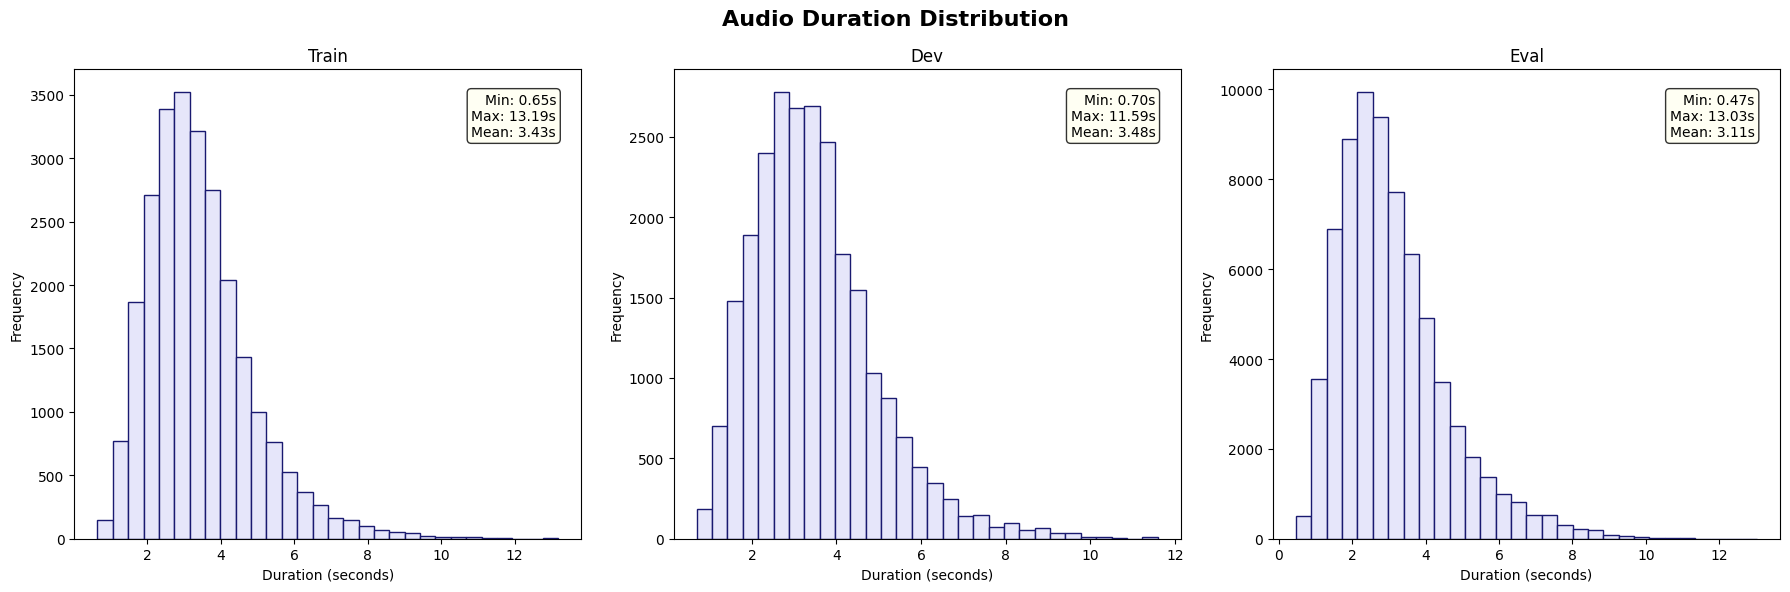

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, dataset in enumerate([train_data, dev_data, eval_data]):

    durations = []
    for _, _, meta in dataset:
        info = sf.info(meta.path)
        durations.append(info.duration)
        
    ax = axes[idx]
    ax.hist(durations, bins=30, facecolor='lavender', edgecolor='midnightblue')
    ax.set_xlabel('Duration (seconds)')
    ax.set_ylabel('Frequency')
    ax.set_title(dataset.dset_name.capitalize())

    stats_text = f"Min: {min(durations):.2f}s\nMax: {max(durations):.2f}s\nMean: {np.mean(durations):.2f}s"
    ax.text(0.95, 0.95, stats_text, 
         transform=ax.transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='ivory', alpha=0.8))

fig.suptitle('Audio Duration Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Examples
Playback + visualizations (waveforms and spectrograms)

In [10]:
demo_indices = [0, 3000, 3000 + 3800 * 2, 3000 + 3800 * 4]

In [11]:
for i in demo_indices:
    audio, label, meta = train_data[i]
    print(f"\n{'Bonafide' if label == 1.0 else 'Spoof'} - {meta.file_name}")
    print(f"System: {train_data.sysid_dict_inv[meta.sys_id]}")
    display(Audio(audio, rate=16000))


Bonafide - LA_T_1138215
System: -



Spoof - LA_T_3740126
System: A01



Spoof - LA_T_3711779
System: A03



Spoof - LA_T_3285771
System: A05


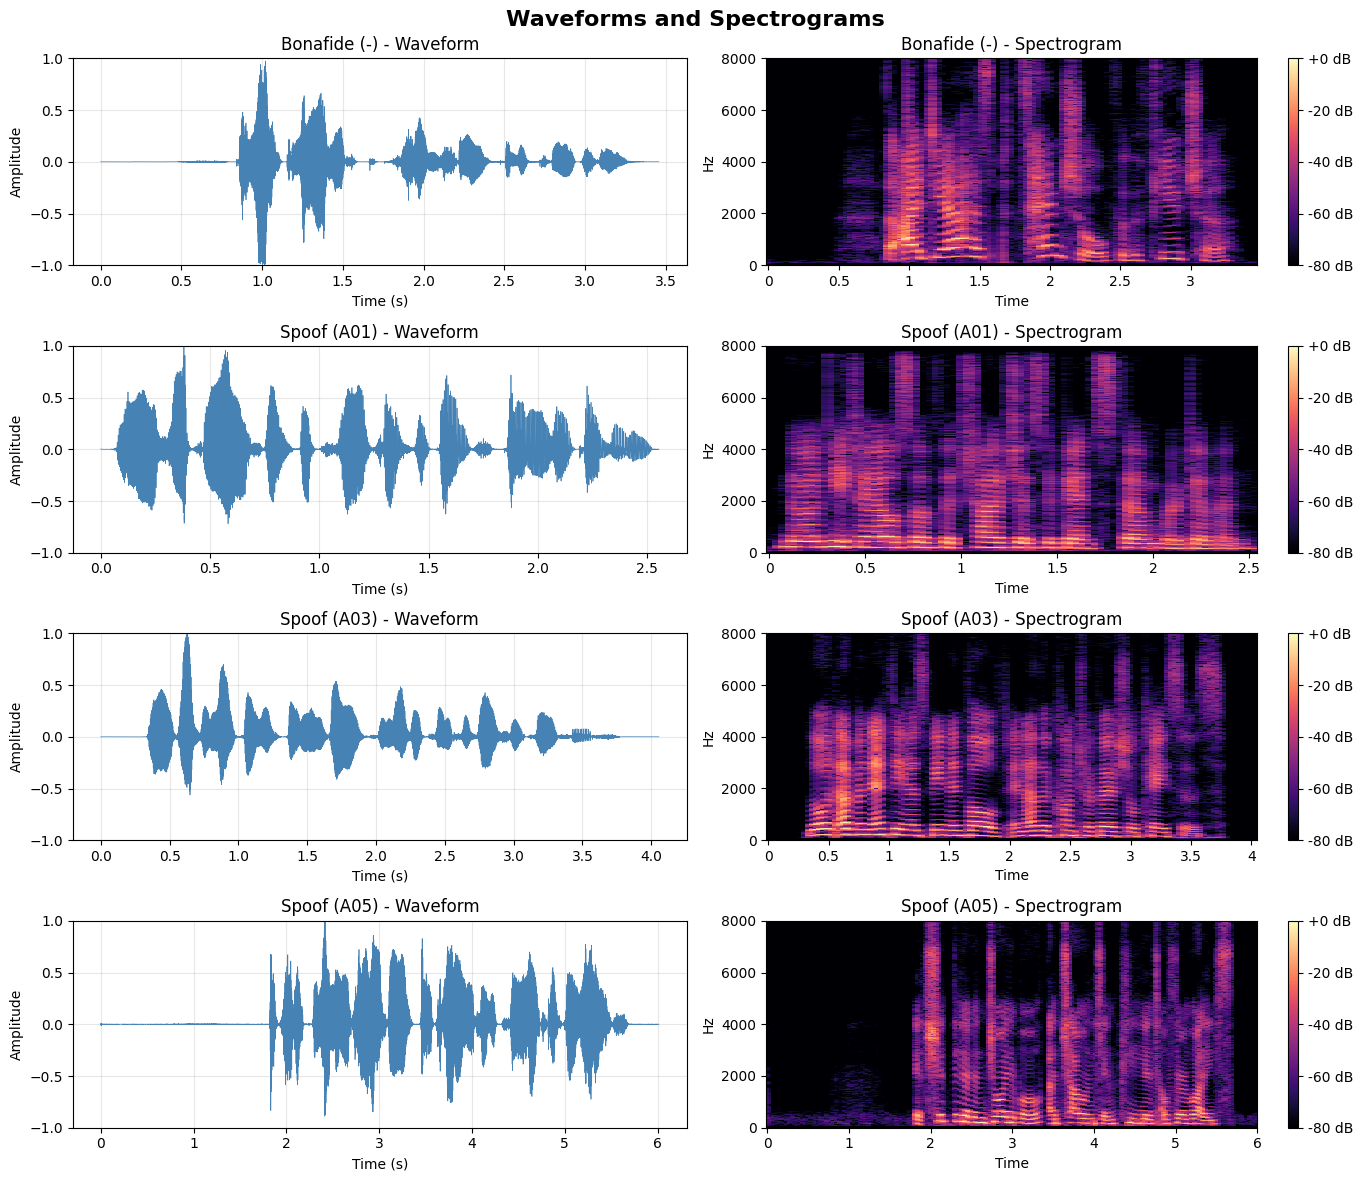

In [12]:
fig, axes = plt.subplots(len(demo_indices), 2, figsize=(14, 3*len(demo_indices)))

for idx, sample_idx in enumerate(demo_indices):
    audio, label, meta = train_data[sample_idx]
    sys_name = train_data.sysid_dict_inv[meta.sys_id]
    label_name = 'Bonafide' if label == 1.0 else 'Spoof'
    
    # Waveform
    ax_wave = axes[idx, 0]
    time = np.arange(len(audio)) / 16000
    ax_wave.plot(time, audio, linewidth=0.5, color='steelblue')
    ax_wave.set_title(f'{label_name} ({sys_name}) - Waveform')
    ax_wave.set_xlabel('Time (s)')
    ax_wave.set_ylabel('Amplitude')
    ax_wave.set_ylim(-1, 1)
    ax_wave.grid(alpha=0.3)
    
    # Spectrogram
    ax_spec = axes[idx, 1]
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    img = librosa.display.specshow(D, sr=16000, x_axis='time', y_axis='hz', 
                                    ax=ax_spec, cmap='magma')
    ax_spec.set_title(f'{label_name} ({sys_name}) - Spectrogram')
    plt.colorbar(img, ax=ax_spec, format='%+2.0f dB')

fig.suptitle('Waveforms and Spectrograms', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()